<a href="https://colab.research.google.com/github/rrohanj/MLREPO/blob/main/week10(ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori,association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx
print("MARKET BASKET ANALYSIS")
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

MARKET BASKET ANALYSIS


In [2]:
transactions=[
    ['Bread',"Milk",'Eggs'],
    ['Bread',"Butter","Jam"],
    ["Milk","Bread","Butter"],
    ['Bread',"Milk","Butter","Eggs"],
    ["Milk","Eggs","Cereal"],
    ["Bread","Eggs","Milk"],
    ["Butter","Jam","Bread"],
    ["Bread","Milk","Butter"],
    ["Milk","Cereal","Eggs"],
    ["Bread","Butter","Jam","Milk"]
]
print(len(transactions))
print("Sample Transactions:")
for i in range(3):
  print(f"Transactions {i+1}:{transactions[i]}")

10
Sample Transactions:
Transactions 1:['Bread', 'Milk', 'Eggs']
Transactions 2:['Bread', 'Butter', 'Jam']
Transactions 3:['Milk', 'Bread', 'Butter']


In [3]:
te=TransactionEncoder()
te_arr=te.fit(transactions).transform(transactions)
df=pd.DataFrame(te_arr,columns=te.columns_)
print("Binary matrix (first 5 rows)")
print(df.head())

Binary matrix (first 5 rows)
   Bread  Butter  Cereal   Eggs    Jam   Milk
0   True   False   False   True  False   True
1   True    True   False  False   True  False
2   True    True   False  False  False   True
3   True    True   False   True  False   True
4  False   False    True   True  False   True


In [5]:
print("STATISTICS")
item=df.sum().sort_values(ascending=False)
print("Item frequencies")
print(item)
trans=[len(t) for t in transactions]
print(f"Average Items: {np.mean(trans):.2f}")
print(f"Min Items: {np.min(trans)}")
print(f"Max Items: {np.max(trans)}")

STATISTICS
Item frequencies
Bread     8
Milk      8
Butter    6
Eggs      5
Jam       3
Cereal    2
dtype: int64
Average Items: 3.20
Min Items: 3
Max Items: 4


In [6]:
print("APRIORI RESULTS")
support=0.3
itemsets=apriori(df,min_support=support,use_colnames=True)
print(f"Frequent Itemsets (support>={support}):")
print(f"Total: {len(itemsets)}")
print(itemsets)

APRIORI RESULTS
Frequent Itemsets (support>=0.3):
Total: 15
    support               itemsets
0       0.8                (Bread)
1       0.6               (Butter)
2       0.5                 (Eggs)
3       0.3                  (Jam)
4       0.8                 (Milk)
5       0.6        (Butter, Bread)
6       0.3          (Bread, Eggs)
7       0.3           (Jam, Bread)
8       0.6          (Bread, Milk)
9       0.3          (Jam, Butter)
10      0.4         (Butter, Milk)
11      0.5           (Milk, Eggs)
12      0.3   (Jam, Butter, Bread)
13      0.4  (Butter, Bread, Milk)
14      0.3    (Bread, Milk, Eggs)


In [7]:
rules=association_rules(itemsets,metric='lift',min_threshold=1.0)
print(f"Association rules generated {len(rules)}")
print("All Rules")
print(rules[['antecedents','consequents','support','confidence','lift']])

Association rules generated 22
All Rules
        antecedents      consequents  support  confidence      lift
0          (Butter)          (Bread)      0.6    1.000000  1.250000
1           (Bread)         (Butter)      0.6    0.750000  1.250000
2             (Jam)          (Bread)      0.3    1.000000  1.250000
3           (Bread)            (Jam)      0.3    0.375000  1.250000
4             (Jam)         (Butter)      0.3    1.000000  1.666667
5          (Butter)            (Jam)      0.3    0.500000  1.666667
6            (Milk)           (Eggs)      0.5    0.625000  1.250000
7            (Eggs)           (Milk)      0.5    1.000000  1.250000
8     (Jam, Butter)          (Bread)      0.3    1.000000  1.250000
9      (Jam, Bread)         (Butter)      0.3    1.000000  1.666667
10  (Butter, Bread)            (Jam)      0.3    0.500000  1.666667
11            (Jam)  (Butter, Bread)      0.3    1.000000  1.666667
12         (Butter)     (Jam, Bread)      0.3    0.500000  1.666667
13     

In [8]:
rules=rules[rules['confidence']>=0.5]
print(f"Rules with confidence >=0.5: {len(rules)}")

Rules with confidence >=0.5: 19


In [11]:
print("TOP RULES")
print("TOP 5 RULES BY LIFT")
top_lift=rules.nlargest(5,'lift')
for i,(idx,row) in enumerate(top_lift.iterrows(),1):
  ante=','.join(list(row['antecedents']))
  cons=",".join(list(row['consequents']))
  print(f"{i}.{ante}->{cons}")
  print(f"Support: {row['support']:.3f}")
  print(f"Confidence: {row['confidence']:.2f}")
  print(f"Lift: {row['lift']:.2f}")

TOP RULES
TOP 5 RULES BY LIFT
1.Jam->Butter
Support: 0.300
Confidence: 1.00
Lift: 1.67
2.Butter->Jam
Support: 0.300
Confidence: 0.50
Lift: 1.67
3.Jam,Bread->Butter
Support: 0.300
Confidence: 1.00
Lift: 1.67
4.Butter,Bread->Jam
Support: 0.300
Confidence: 0.50
Lift: 1.67
5.Jam->Butter,Bread
Support: 0.300
Confidence: 1.00
Lift: 1.67


In [14]:
print("TOP 5 RULES BY CONFIDENCE:")
top_conf=rules.nlargest(5,'confidence')
for i,(idx,row) in enumerate(top_conf.iterrows(),1):
  ante=",".join(list(row['antecedents']))
  cons=",".join(list(row['consequents']))
  print(f"{i} {ante}->{cons}")
  print(f"Support: {row['support']:.2f},Confidence: {row['confidence']:.2f}")
  print(f"Lift: {row['lift']:.2f}")

TOP 5 RULES BY CONFIDENCE:
1 Butter->Bread
Support: 0.60,Confidence: 1.00
Lift: 1.25
2 Jam->Bread
Support: 0.30,Confidence: 1.00
Lift: 1.25
3 Jam->Butter
Support: 0.30,Confidence: 1.00
Lift: 1.67
4 Eggs->Milk
Support: 0.50,Confidence: 1.00
Lift: 1.25
5 Jam,Butter->Bread
Support: 0.30,Confidence: 1.00
Lift: 1.25


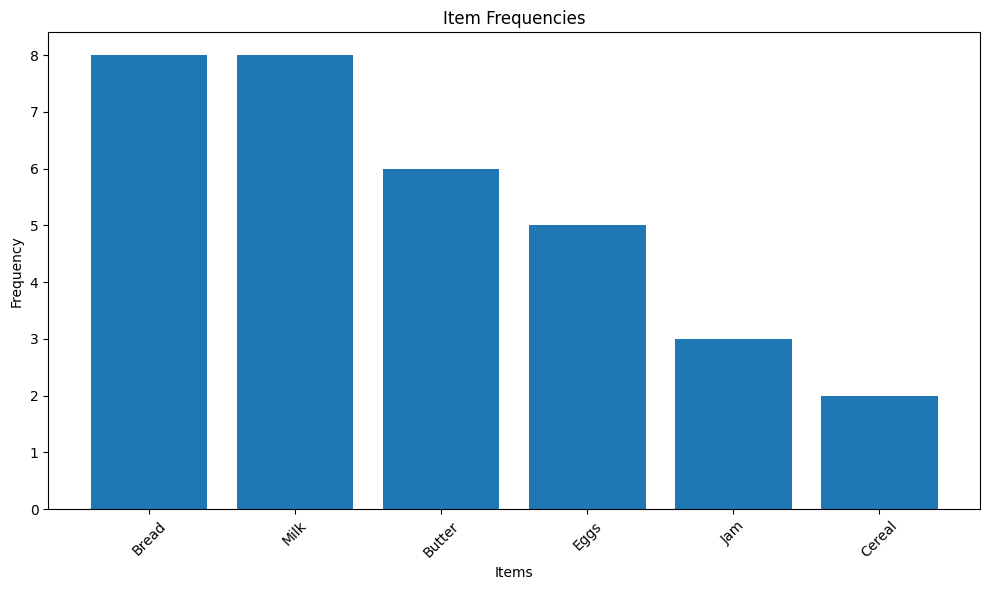

In [16]:
plt.figure(figsize=(10,6))
plt.bar(range(len(item)),item.values)
plt.xticks(range(len(item)),item.index,rotation=45)
plt.title('Item Frequencies')
plt.xlabel("Items")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

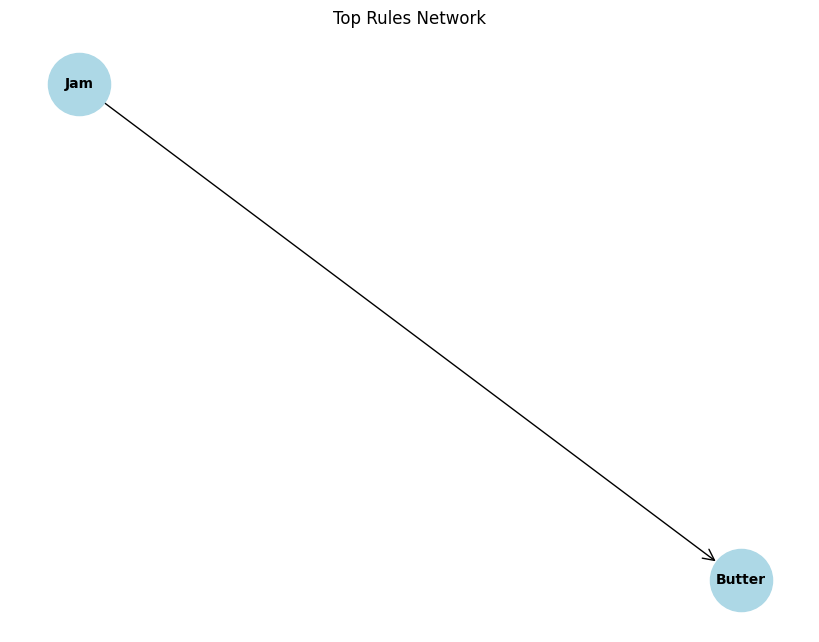

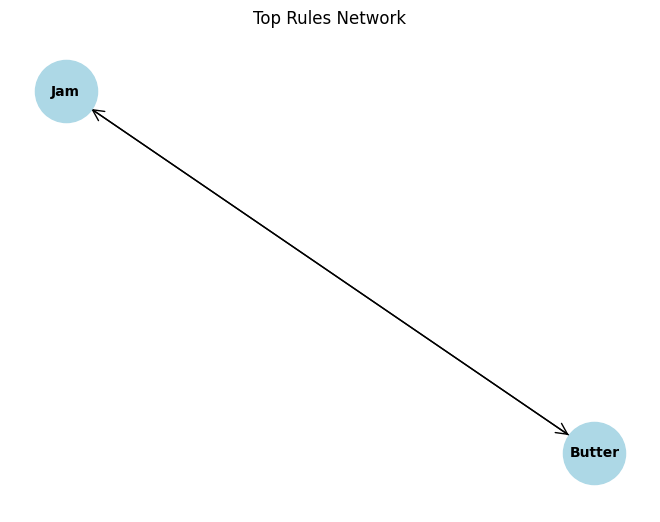

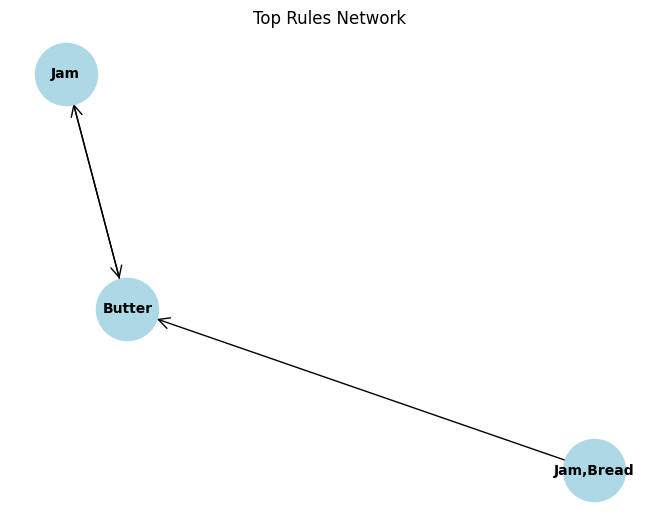

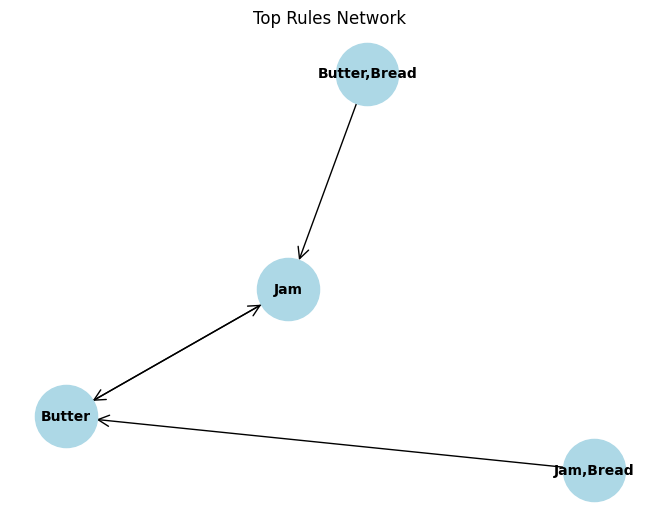

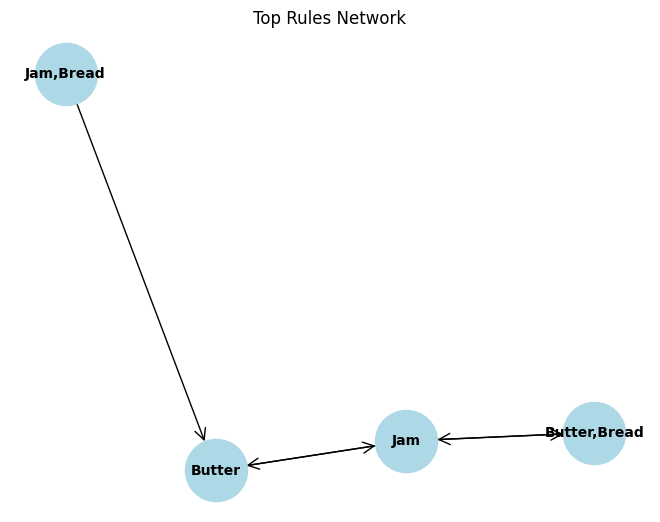

In [17]:
if len(rules)>0:
  plt.figure(figsize=(8,6))
  g=nx.DiGraph()
  for idx,row in top_lift.iterrows():
    ante=",".join(list(row['antecedents']))
    cons=','.join(list(row['consequents']))
    g.add_edge(ante,cons,weight=row['lift'])
    pos=nx.spring_layout(g)
    nx.draw(g,pos,with_labels=True,node_color='lightblue',node_size=2000
            ,font_size=10,font_weight="bold",arrows=True,arrowstyle="->",
            arrowsize=20)
    plt.title("Top Rules Network")
    plt.show()

In [18]:
print("BUSINESS INTERPRETATION")
print("What the rules mean:")
print("If a customer buys [Item A],they will likely to also buy [item B]")
print("Lift> 1 means items are positively associated")
print("Confidence show how often the rule holds true")
print("Key Finding:")
if len(rules)>0:
  best=rules.nlargest(1,'lift').iloc[0]
  ante=','.join(best['antecedents'])
  cons=','.join(best['consequents'])
  print(f'Strongest Associations: {ante}->{cons}')
  print(f"Lift: {best['lift']:.2f}")
print("Markerting Suggestions")
print("1. Store Layout: Place associated items near each other")
print("2. Promotions: Offer discounts on pairs that are frequently bought together")
print("3. Cross-selling: Train staff to suggest complementary items")
print("4. Product placement: Create themed displays (e.g. breakfast section)")

rules[['antecedents','consequents','support','confidence','lift']].to_csv('simple_rules.csv',index=False)
print("Results saved to simple_rules.csv")

BUSINESS INTERPRETATION
What the rules mean:
If a customer buys [Item A],they will likely to also buy [item B]
Lift> 1 means items are positively associated
Confidence show how often the rule holds true
Key Finding:
Strongest Associations: Jam->Butter
Lift: 1.67
Markerting Suggestions
1. Store Layout: Place associated items near each other
2. Promotions: Offer discounts on pairs that are frequently bought together
3. Cross-selling: Train staff to suggest complementary items
4. Product placement: Create themed displays (e.g. breakfast section)
Results saved to simple_rules.csv


In [19]:
import pandas as pd
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Part A: Data Loading (Grocery Dataset)
dataset = [['Milk', 'Bread', 'Butter'],
           ['Bread', 'Butter'],
           ['Milk', 'Bread'],
           ['Milk', 'Butter', 'Bread', 'Eggs'],
           ['Bread', 'Butter', 'Eggs']]

# Preprocessing into binary matrix [cite: 609]
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Part B: FP-Growth vs Apriori Timing
start = time.time()
frequent_itemsets_apriori = apriori(df, min_support=0.4, use_colnames=True)
apriori_time = time.time() - start

start = time.time()
frequent_itemsets_fp = fpgrowth(df, min_support=0.4, use_colnames=True)
fpgrowth_time = time.time() - start

# Part C: Rule Generation [cite: 614, 615]
rules = association_rules(frequent_itemsets_fp, metric="lift", min_threshold=1.0)

print(f"Apriori Time: {apriori_time:.5f}s")
print(f"FP-Growth Time: {fpgrowth_time:.5f}s")
print("\nTop Association Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

Apriori Time: 0.01429s
FP-Growth Time: 0.01636s

Top Association Rules:
      antecedents consequents  support  confidence  lift
0        (Butter)     (Bread)      0.8         1.0   1.0
1         (Bread)    (Butter)      0.8         0.8   1.0
2         (Bread)      (Milk)      0.6         0.6   1.0
3          (Milk)     (Bread)      0.6         1.0   1.0
4  (Butter, Milk)     (Bread)      0.4         1.0   1.0


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
